Korzystanie z narzędzi generatywnej AI w rozwiązywaniu zadań nie jest dozwolone

<img src="no_AI.png" alt="Use of AI allowed only when properly documented " width="100" height="100">

# Zadanie obowiązkowe [0-10] pkt

1. [0-1.5 pkt] Używając [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html), dokonaj przeszukania przestrzeni hiperparametrów SVC, zmieniając (uargumentuj wybór):
   1. funkcję jądra
   1. paramety jądra
   1. parametr `C`
1. [0-1 pkt] W przeszukaniu wyżej użyj [walidacji krzyżowej](https://scikit-learn.org/stable/modules/cross_validation.html) odpowiedniej dla zbioru niezbalansowanego
1. [0-1.5 pkt] Zbadaj zależność liczby wektorów nośnych per klasa. W tym celu wykorzystaj atrybuty `support_vectors_` i/lub `decision_function`. Czy istnieje korelacja między liczbą wektorów nośnych a dokładnością klasyfikatora?
2. [0-1 pkt] Podobnie jak w poprzednim zadaniu, zbadaj dokładność modelu w zależności od techniki skalowania oraz wyboru liczby cech
3. [0-1.5 pkt] Dla najlepszej pary `n_features_to_select=2` wyrysuj obszary decyzyjne. Weź pod uwagę, że implementacja w `scikit-learn`  działa na zasadzie OvR (*One-vs-Rest*) tzn. każdy klasyfikator uczy się oddzielnej hiperpowierzchni dla swojej klasy. Skomentuj wyniki
1. [0-1 pkt] Porównaj wyniki najlepszego modelu z `LinearSVC` z domyślnymi parametrami. Użyj MCC jako miary do porównania (uwzględnij odchylenie standardowe po podziałach w walidacji krzyżowej). Skomentuj wynik
1. [0-1 pkt] Czy w świetle uzyskanych wyników, SVC jest odpowiednim klasyfikatorem do tego problemu? Uzasadnij odpowiedź
1. [0-1.5 pkt] Zidentyfikuj używkę, z którą model radzi sobie najlepiej. Analiza nie musi być tak zaawansowana jak wyżej, ale powinna miarodajnie porównać wszystkie klasyfikatory między sobą. Efektywnie, chodzi o zaimplementowanie pętli po zmiennej `y` i odpowiednie dobranie parametrów w `GridSearchCV` oraz `Pipeline`
   
<span style="color:red">**Uwaga:**</span> zadania bez komentarzy i wniosków zostaną ocenione na **0 punktów**.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from ucimlrepo import fetch_ucirepo 
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import KFold, GridSearchCV, StratifiedKFold
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import f1_score, matthews_corrcoef, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

In [3]:
drugs = fetch_ucirepo(id=373) 
X = drugs.data.features 
y_all = drugs.data.targets
# Przewidujemy doświadczenia z grzybami halucynogennymi
y = y_all.mushrooms

In [4]:
idx_to_drop = y_all[y_all['semer'] != 'CL0'].index
X = X.drop(idx_to_drop)
y = y.drop(idx_to_drop)

idx_to_drop = y[y == 'CL6'].index
X = X.drop(idx_to_drop)
y = y.drop(idx_to_drop)

In [5]:
label_encoder = LabelEncoder()

y_trans = label_encoder.fit_transform(y.values)

In [6]:
# Zbiór treningowy stanowi 80% całego zbioru (5 podziałów)
rkf = KFold(n_splits=5)
for i, (idx_train, idx_test) in enumerate(rkf.split(X, y_trans)):
    # Wybór modelu
    svc = SVC(kernel='linear', max_iter=10_000, C=1, random_state=0)
    # Podział zbioru na dane treningowe i testowe
    X_train = X.iloc[idx_train]
    y_train = y_trans[idx_train]
    X_test = X.iloc[idx_test]
    y_test = y_trans[idx_test]
    # Trening modelu
    svc.fit(X_train, y_train)
    y_pred_train = svc.predict(X_train)
    y_pred_test  = svc.predict(X_test)
    # Miary dokładności
    f1_train = f1_score(y_train, y_pred_train, average='macro')
    f1_test = f1_score(y_test, y_pred_test, average='macro')
    mcc_train = matthews_corrcoef(y_train, y_pred_train)
    mcc_test = matthews_corrcoef(y_test, y_pred_test)
    print(f"{i+1} iteracja, train: ({f1_train:.2f}, {mcc_train:.2f}), test: ({f1_test:.2f}, {mcc_test:.2f})")

1 iteracja, train: (0.19, 0.22), test: (0.21, 0.04)
2 iteracja, train: (0.20, 0.25), test: (0.16, 0.12)
3 iteracja, train: (0.20, 0.24), test: (0.15, 0.11)
4 iteracja, train: (0.19, 0.20), test: (0.19, 0.22)
5 iteracja, train: (0.19, 0.23), test: (0.21, 0.28)


Wykonałem wstępne przetwarzanie danych, które zostało już wykonane w głównej treści laboratorium. Usunięto dane z zaburzonymi wynikami oraz najrzadsze spośród kategorii.

In [7]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(max_iter=10_000, random_state=0))
])

param_grid = [
    {
        'svc__kernel': ['linear'],
        'svc__C': [0.01, 0.1, 1, 10, 100]
    },
    {
        'svc__kernel': ['rbf'],
        'svc__C': [0.01, 0.1, 1, 10, 100],
        'svc__gamma': ['scale', 0.001, 0.01, 0.1, 1]
    },
    {
        'svc__kernel': ['poly'],
        'svc__C': [0.01, 0.1, 1, 10],
        'svc__degree': [2, 3, 4],
        'svc__gamma': ['scale', 0.01, 0.1]
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    scoring='f1_macro', 
    cv=cv, 
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y_trans)

print("Najlepsze parametry:")
print(grid_search.best_params_)

print("Najlepszy wynik F1 (macro):")
print(grid_search.best_score_)

Fitting 5 folds for each of 66 candidates, totalling 330 fits
Najlepsze parametry:
{'svc__C': 10, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}
Najlepszy wynik F1 (macro):
0.2731805207369341


W przeszukaniu uwzględniono następujące hiperparametry:
Jako funkcję jądra (kernel) rozważono 3 typy: linear (dla danych liniowo separowalnych), rbf (modeluje nieliniowości) i poly (pozwala uchwycić bardziej złożone zależności). Dzięki temu można sprawdzić czy problem jest liniowy czy nieliniowy.

Parametr C zmieniam w zakresie 0.01 do 100. Dzięki przeskokowi logarytmicznemu można sprawdzić różne skale modelu. Dla małych wartości będzie większa regularyzacja, a więc prostszy model, a dla dużych wartości parametr kontroluje dopasowanie do danych.

Dla funkcji jądra rbf zmieniam parametr gamma, który kontroluje zasięg wpływu punktów. Dla małych wartości będzie bardziej gładka granica, a dla większych bardziej złożona.

Dla funkcji polynomial oprócz parametru gamma zmieniam też stopień wielomianu, co pozwala mi modelować bardziej złożone zależności.

Zastosowałem także skalowanie danych w postaci StandardScalera, bo SVM jest wrażliwy na skalę cech, a brak skalowania może pogorszyć wyniki.

Jako walidację krzyżową zastosowałem StratifiedKFold, dzięki czemu zachowuję proporcję klas w każdym foldzie. Zapobiega to sytuacji, gdzie jakaś klasa znika w zbiorze treningowym lub testowym. 

Jako metrykę oceny użyłem f1_macro, bo traktuje ona wszystkie klasy równo i nie faworyzuje dominującej klasy.

Fold 1: SV = 1169, F1 = 0.2087
Fold 2: SV = 1198, F1 = 0.2511
Fold 3: SV = 1183, F1 = 0.2645
Fold 4: SV = 1166, F1 = 0.2386
Fold 5: SV = 1171, F1 = 0.2282

Korelacja SV vs F1: 0.6380712945118958


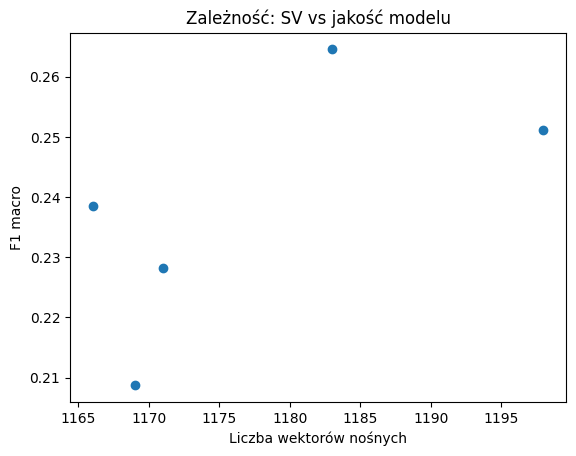

In [10]:
sv_counts = []
accuracies = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

for i, (train_idx, test_idx) in enumerate(cv.split(X, y_trans)):
    model = SVC(kernel='rbf', C=1, gamma='scale', random_state=0)

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_trans[train_idx], y_trans[test_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    acc = f1_score(y_test, y_pred, average='macro')
    accuracies.append(acc)

    sv_counts.append(len(model.support_vectors_))

    print(f"Fold {i+1}: SV = {len(model.support_vectors_)}, F1 = {acc:.4f}")

corr = np.corrcoef(sv_counts, accuracies)[0, 1]
print("\nKorelacja SV vs F1:", corr)

plt.figure()
plt.scatter(sv_counts, accuracies)
plt.xlabel("Liczba wektorów nośnych")
plt.ylabel("F1 macro")
plt.title("Zależność: SV vs jakość modelu")
plt.show()

Jak możemy zauważyć z powyższego wykresu, nie występuje silna korelacja między liczbą wektorów nośnych, a jakością modelu. Nie determinuje ona jakości modelu.

In [15]:
scalers = {
    "none": None,
    "standard": StandardScaler(),
    "minmax": MinMaxScaler(),
    "robust": RobustScaler()
}

feature_counts = [3, 5, X.shape[1]]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

results = []

for scale_name, scaler in scalers.items():
    for k in feature_counts:
        f1_scores = []
        selector = SelectKBest(score_func=f_classif, k=k)

        for train_idx, test_idx in cv.split(X, y_trans):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y_trans[train_idx], y_trans[test_idx]

            X_train_sel = selector.fit_transform(X_train, y_train)
            X_test_sel = selector.transform(X_test)

            if scaler is not None:
                X_train_sel = scaler.fit_transform(X_train_sel)
                X_test_sel = scaler.transform(X_test_sel)

            model = SVC(kernel='rbf', C=1, gamma='scale')

            model.fit(X_train_sel, y_train)
            y_pred = model.predict(X_test_sel)

            f1_scores.append(f1_score(y_test, y_pred, average='macro'))

        mean_f1 = np.mean(f1_scores)

        results.append({
            "scaler": scale_name,
            "k_features": k,
            "f1_macro": mean_f1
        })

        print(f"Scaler: {scale_name}, K: {k}, F1 macro: {mean_f1:.4f}")

df_results = pd.DataFrame(results)
df_results 

Scaler: none, K: 3, F1 macro: 0.2720
Scaler: none, K: 5, F1 macro: 0.2544
Scaler: none, K: 12, F1 macro: 0.2323
Scaler: standard, K: 3, F1 macro: 0.2698
Scaler: standard, K: 5, F1 macro: 0.2570
Scaler: standard, K: 12, F1 macro: 0.2382
Scaler: minmax, K: 3, F1 macro: 0.2581
Scaler: minmax, K: 5, F1 macro: 0.2411
Scaler: minmax, K: 12, F1 macro: 0.2289
Scaler: robust, K: 3, F1 macro: 0.2709
Scaler: robust, K: 5, F1 macro: 0.2502
Scaler: robust, K: 12, F1 macro: 0.2226


,scaler,k_features,f1_macro
0,none,3,0.272047
1,none,5,0.254436
2,none,12,0.232276
3,standard,3,0.269830
4,standard,5,0.257010
5,standard,12,0.238214
6,minmax,3,0.258062
7,minmax,5,0.241138
8,minmax,12,0.228860
9,robust,3,0.270925


Sprawdziłem wpływ techniki skalowania danych oraz liczby wybranych cech na jakość klasyfikatora SVM (SVC z jądrem RBF). Zastosowałem walidację krzyżową StratifiedKFold oraz selekcję cech metodą SelectKBest.

Przeanalizowałem 4 metody skalowania: brak skalowania, StandardScaler, MinMaxScaler i RobustScaler oraz 3 warianty liczby cech (3, 5, wszystkie cechy (12)). Wyniki pokazują, że liczba cech ma większy wpływ na jakość modelu niż sama technika skalowania. Najlepsze wyniki uzyskano dla małej liczby cech, natomiast zwiększanie liczby cech powodowało spadek jakości klasyfikacji. Różnice między metodami skalowania były niewielkie. MinMaxScaler dawał nieco gorsze wyniki.

W tym zbiorze danych kluczowa zatem jest redukcja liczby cech. Wybór skalowania jest drugorzędny.

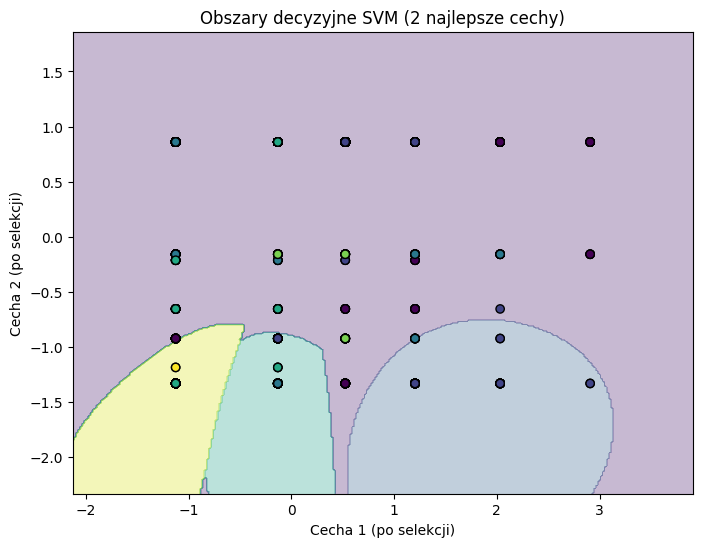

In [17]:
selector = SelectKBest(score_func=f_classif, k=2)
X_sel = selector.fit_transform(X, y_trans)

selected_features_idx = selector.get_support(indices=True)

scaler = StandardScaler()
X_sel = scaler.fit_transform(X_sel)

model = SVC(kernel='rbf', C=1, gamma='scale')
model.fit(X_sel, y_trans)

x_min, x_max = X_sel[:, 0].min() - 1, X_sel[:, 0].max() + 1
y_min, y_max = X_sel[:, 1].min() - 1, X_sel[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300), 
    np.linspace(y_min, y_max, 300)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)

scatter = plt.scatter(
    X_sel[:, 0],
    X_sel[:, 1],
    c=y_trans,
    edgecolor='k'
)

plt.title("Obszary decyzyjne SVM (2 najlepsze cechy)")
plt.xlabel("Cecha 1 (po selekcji)")
plt.ylabel("Cecha 2 (po selekcji)")
plt.show()

Z pomocą SelectKBest z testem f_classif wybrałem 2 cechy o największej sile dyskryminacyjnej. Wygenerowałem siatkę punktów (mesh-grid) dla której model dokonał predykcji, tworząc mapę obszarów decyzyjnych dla poszczególnych klas.

Punkty na wykresie układają się w regularną strukturę siatki, co sugeruje, że wybrane cechy mają charakter dyskretny lub porządkowy, a nie ciągły. Widoczne jest silne mieszanie się klas w tych samych punktach przestrzeni. To sprawia, że granice decyzyjne są poszarpane lub tworzą odizolowane wyspy. Model wyznaczył rozległy obszar fioletowy dla klasy dominującej, a dla pozostałych stworzył mniejsze enklawy w dolnej części wykresu. Specyficzne zaokrąglone kształty obszarów są typowe dla jądra RBF, które próbuje otoczyć skupiska punktów danej klasy. W tym przypadku widać, że model ma trudności z liniowym odseparowaniem danych, co potwierdza zasadność użycia nieliniowego jądra. Wybrane cechy pozwalają jedynie częściowo rozróżnić klasy. Silne nakładanie się punktów sugeruje, że te dwie cechy mogą być niewystarczające do budowy w pełni skutecznego klasyfikatora.

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

mcc_svc = []
mcc_linear = []

for train_idx, test_idx in cv.split(X, y_trans):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_trans[train_idx], y_trans[test_idx]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    svc = SVC(kernel='rbf', C=1, gamma='scale')
    svc.fit(X_train, y_train)
    pred_svc = svc.predict(X_test)
    mcc_svc.append(matthews_corrcoef(y_test, pred_svc))

    linear = LinearSVC(random_state=0, max_iter=10_000)
    linear.fit(X_train, y_train)
    pred_linear = linear.predict(X_test)
    mcc_linear.append(matthews_corrcoef(y_test, pred_linear))

print("SVC MCC: mean =", np.mean(mcc_svc), "std =", np.std(mcc_svc))
print("LinearSVC MCC: mean =", np.mean(mcc_linear), "std =", np.std(mcc_linear))

SVC MCC: mean = 0.24298715161681644 std = 0.03762109105736087
LinearSVC MCC: mean = 0.2415969973199858 std = 0.014711443401185615


Przeprowadzono porównanie modeli SVC z jądrem RBF oraz LinearSVC przy użyciu współczynnika Matthews Correlation Coefficient (MCC) w walidacji krzyżowej.

Oba modele uzyskały zbliżone wartości MCC, co sugeruje, że różnica w jakości predykcji jest niewielka.

SVC osiąga minimalnie wyższą średnią wartość MCC, co może wskazywać na lepsze dopasowanie do nieliniowych zależności w danych. LinearSVC charakteryzuje się mniejszym odchyleniem standardowym, co oznacza bardziej stabilne wyniki między foldami. Różnice są niewielkie, więc można uznać, że modele mają porównywalną skuteczność dla tego zbioru danych.

Na podstawie uzyskanych wyników można stwierdzić, że SVC jest odpowiednim klasyfikatorem dla tego problemu, jednak jego przewaga nad LinearSVC jest minimalna. Prawdopodobnie dane nie mają silnie nieliniowej struktury. Prostszy model LinearSVC może być wystarczający, a zastosowanie jądra RBF nie daje znaczącej poprawy jakości.

W tym przypadku wybór bardziej złożonego modelu z RBF nie przynosi istotnej poprawy wyników, dlatego LinearSVC może być równie dobrym, a nawet bardziej stabilnym wyborem.

In [19]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC())
])

param_grid = {
    "svc__kernel": ['linear', 'rbf'],
    "svc__C": [0.1, 1, 10],
    "svc__gamma": ['scale', 0.1, 1]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

grid = GridSearchCV(
    pipe, 
    param_grid=param_grid, 
    scoring='f1_macro', 
    cv=cv, 
    n_jobs=-1
)

grid.fit(X, y_trans)

best_model = grid.best_estimator_

y_pred = best_model.predict(X)

class_f1 = f1_score(y_trans, y_pred, average=None)
class_names = label_encoder.inverse_transform(np.unique(y_trans))

results = pd.DataFrame({
    "class": class_names,
    "f1_score": class_f1
}).sort_values(by="f1_score", ascending=False)

print(results)

best_class = results.iloc[0]
print("\nNajlepiej klasyfikowana klasa:")
print(best_class)

  class  f1_score
0   CL0  0.910671
1   CL1  0.833333
3   CL3  0.807692
2   CL2  0.786177
4   CL4  0.765550
5   CL5  0.721311

Najlepiej klasyfikowana klasa:
class            CL0
f1_score    0.910671
Name: 0, dtype: object


W ramach eksperymentu zbudowałem pipeline składający się ze standaryzacji danych. Po wytrenowaniu najlepszego modelu dokonałem analizy jego skuteczności dla poszczególnych klas, obliczając F1-score osobno dla każdej z nich.

Najwyższą skuteczność uzyskano dla klasy CL0 z F1 około 0.91, co oznacza, że model całkiem dobrze rozpoznaje tę klasę. Pozostałe klasy osiągają niższe, ale nadal relatywnie wysokie wartości F1-score (ok. 0.72-0.83).

Wyraźna przewaga klasy CL0 sugeruje, że jest ona najlepiej reprezentowana lub najbardziej odseparowana w przestrzeni cech, jej obserwacje są najbardziej jednorodne, a model najrzadziej myli ją z innymi klasami. Niższe wyniki dla pozostałych klas mogą wynikać z ich większego nakładania się na siebie oraz większej trudności w ich rozróżnieniu.